nstate1_t5-18_svd1e-12_e0prior
nstate1_t6-18_svd1e-12_e0prior
nstate2_t2-10_svd1e-12_fold
nstate2_t2-15_svd1e-12_fold
nstate2_t2-18_svd1e-12_e0prior
nstate2_t3-15_svd1e-04
nstate2_t3-15_svd1e-12
nstate2_t3-15_svd1e-12_fold
nstate2_t3-18_svd1e-12_e0prior
nstate2_t4-12_svd1e-12_fold
nstate2_t4-15_svd1e-12
nstate2_t4-15_svd1e-12_fold
nstate2_t4-18_svd1e-12_e0prior
nstate2_t5-12_svd1e-12_fold
nstate2_t5-15_svd1e-12
nstate2_t5-15_svd1e-12_fold
nstate2_t5-16_svd1e-12_fold
nstate2_t5-17_svd1e-12_fold
nstate2_t5-18_svd1e-12_e0prior
nstate2_t5-18_svd1e-12_fold
nstate2_t6-15_svd1e-12
nstate2_t6-15_svd1e-12_fold
nstate2_t6-18_svd1e-12_e0prior
nstate2_t7-15_svd1e-12_fold
nstate2_t7-18_svd1e-12_e0prior
nstate2_t8-18_svd1e-12_e0prior
nstate3_t1-18_svd1e-12_e0prior
nstate3_t2-18_svd1e-12_e0prior
nstate3_t3-14_svd1e-12_fold
nstate3_t3-15_svd1e-04
nstate3_t3-15_svd1e-04_fold
nstate3_t3-15_svd1e-12
nstate3_t3-15_svd1e-12_e0prior
nstate3_t3-15_svd1e-12_fold
nstate3_t3-18_svd1e-12_e0prior
nstate3_t4-14_sv

<Figure size 800x600 with 0 Axes>

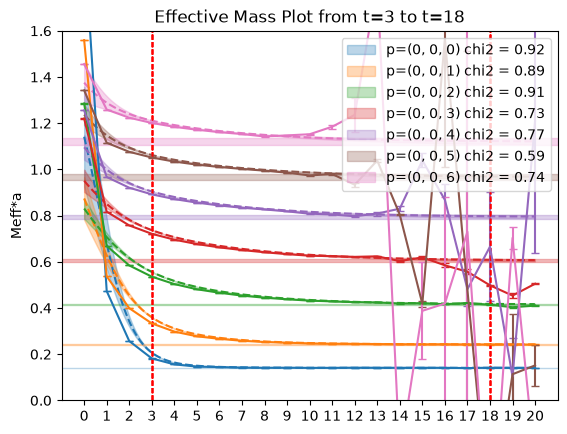

<Figure size 800x600 with 0 Axes>

In [12]:
import numpy as np
import h5py 
import matplotlib.pyplot as plt
f = h5py.File("twopt_fit_results.h5", "r")
for name in f:
    print(name)
fit_window = (3,18)
fit_key = f"nstate3_t{fit_window[0]}-{fit_window[1]}_svd1e-12_e0prior"
for key, value in f[fit_key].items():
    print(f"{key}: {value}")

tmax = 20
p_plot_list=[(0,0,0),(0,0,1),(0,0,2),(0,0,3),(0,0,4),(0,0,5),(0,0,6)]

raw_pt2 = h5py.File("twopt_source_averaged.h5","r")["correlator_cfg"]
raw_pt2_momentum_list = h5py.File("twopt_source_averaged.h5","r")["momentum_list"][:].real
print(f"raw_pt2 has shape {raw_pt2.shape}") 
mom_index_dic = {tuple(p): i for i, p in enumerate(raw_pt2_momentum_list)}

for ip, p in enumerate(p_plot_list):

    group_name = f"p{p[0]}_{p[1]}_{p[2]}"

    group = f[fit_key][group_name]
    chi2dof_central = group["chi2dof_central"][...]
    E_jk=group["E_jk"][...]
    jk_mean_E0 = np.mean(E_jk[:,0],axis=0)
    print(f"For mom = {p}, ground state energy is {jk_mean_E0}")
    jk_err_E0 = np.sqrt((E_jk[:,0].shape[0] - 1.0) / E_jk[:,0].shape[0] * np.sum((E_jk[:,0] - jk_mean_E0) ** 2, axis=0))
    plt.axhspan(jk_mean_E0-jk_err_E0,jk_mean_E0+jk_err_E0 , color="C{}".format(ip), alpha=0.3)
    
    dE_jk=group["dE_jk"][...]
    C_jk=group["C_jk"][...]

    print(f"shape of E_jk is {E_jk.shape}")
    print(f"shape of dE_jk is {dE_jk.shape}")
    print(f"shape of C_jk is {C_jk.shape}")

    t_span = np.linspace(0,tmax,2000)
    dt = t_span[1] - t_span[0]
    two_point = np.zeros((E_jk.shape[0],t_span.shape[0]))
    m_eff = np.zeros((E_jk.shape[0],t_span.shape[0]-1))
    
    for i_jk in range(0,E_jk.shape[0]):
        
        for i_state in range(0,E_jk.shape[1]):
            two_point[i_jk] += C_jk[i_jk,i_state]*np.exp(-E_jk[i_jk,i_state]*t_span)
        m_eff[i_jk] = np.log(two_point[i_jk,:-1]/two_point[i_jk,1:])/dt

    jk_mean_meff = np.mean(m_eff,axis=0)
    jk_err_meff = np.sqrt((m_eff.shape[0] - 1.0) / m_eff.shape[0] * np.sum((m_eff - jk_mean_meff) ** 2, axis=0))

    plt.plot(t_span[:-1],jk_mean_meff,ls="dashed",markersize=0.6)
    plt.fill_between(t_span[:-1], jk_mean_meff-jk_err_meff, jk_mean_meff+jk_err_meff,alpha=0.3,label=f"p={p} chi2 = {chi2dof_central:.2f}",color="C{}".format(ip))
    plt.axvline(x=fit_window[0], color='red', linestyle='--', linewidth=1)
    plt.axvline(x=fit_window[1], color='red', linestyle='--', linewidth=1)

    plt.xticks(np.arange(tmax+1))

    print(f"Momentum {p} has index {mom_index_dic[p]} in the production code momentum list")

    raw_pt2_mom_selected = raw_pt2[:,mom_index_dic[p],:]
    jk_raw_pt2_mom_selected = (np.sum(raw_pt2_mom_selected,axis=0) -raw_pt2_mom_selected)/(raw_pt2_mom_selected.shape[0]-1)
    jk_meff_raw = np.log(jk_raw_pt2_mom_selected[:,:-1]/jk_raw_pt2_mom_selected[:,1:])
    jk_mean_meff_raw = np.mean(jk_meff_raw,axis=0)
    jk_err_meff_raw = np.sqrt((jk_mean_meff_raw.shape[0]-1.0) / jk_mean_meff_raw.shape[0]*np.sum((jk_meff_raw-jk_mean_meff_raw)**2, axis=0))
    
    
    plt.errorbar(range(0,tmax+1),jk_mean_meff_raw[0:tmax+1] , jk_err_meff_raw[0:tmax+1],color="C{}".format(ip),capsize=3)
    

    
plt.title(f"Effective Mass Plot from t={fit_window[0]} to t={fit_window[1]}")     
plt.ylabel(f"Meff*a")
plt.ylim(0, 1.6)
plt.legend()
plt.figure(figsize=(8, 6))   

            

        

        
    